In [51]:
import gymnasium as gym
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from assignment2_utils import describe_env, simulate_episodes, main
from taxi_agent import Agent

## Plots

Observation space:  Discrete(500)
Observation space size:  500
Reward Range:  (-inf, inf)
Number of actions:  6
Action description:  {0: 'Move south (down)', 1: 'Move north (up)', 2: 'Move east (right)', 3: 'Move west (left)', 4: 'Pickup passenger', 5: 'Drop off passenger'}


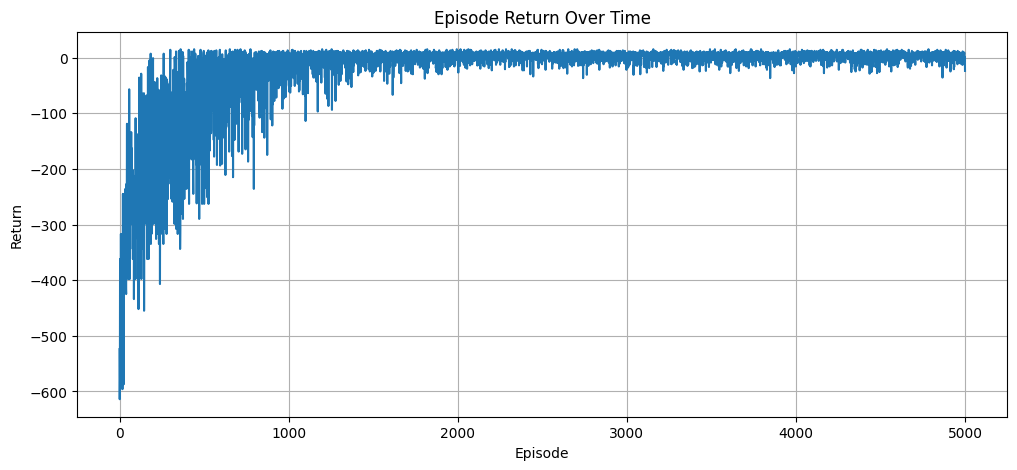

In [52]:
env = gym.make("Taxi-v3")
num_states, num_actions = describe_env(env)

agent = Agent(num_states, num_actions, alpha=0.1, epsilon=0.1, gamma=0.9)
returns, steps = agent.train(env, num_episodes=5000)

plt.figure(figsize=(12,5))
plt.plot(returns)
plt.title("Episode Return Over Time")
plt.xlabel("Episode")
plt.ylabel("Return")
plt.grid(True)
plt.show()

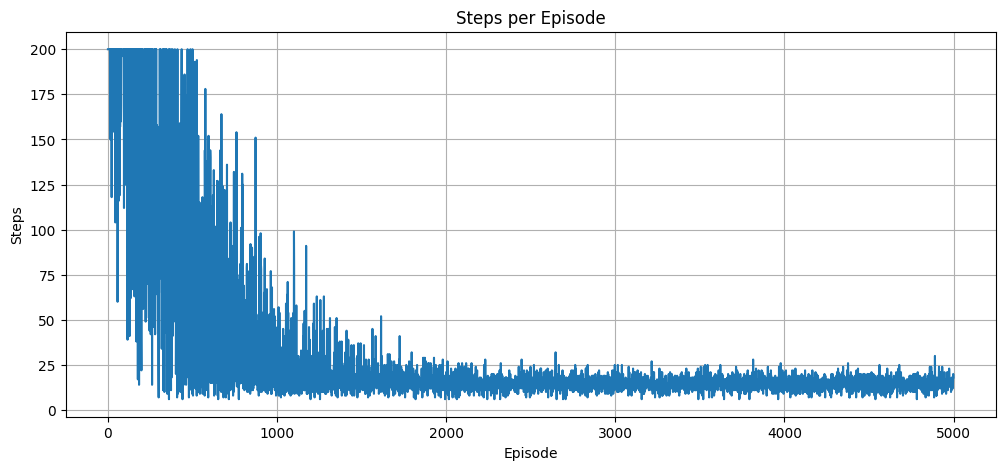

In [53]:
plt.figure(figsize=(12,5))
plt.plot(steps)
plt.title("Steps per Episode")
plt.xlabel("Episode")
plt.ylabel("Steps")
plt.grid(True)
plt.show()

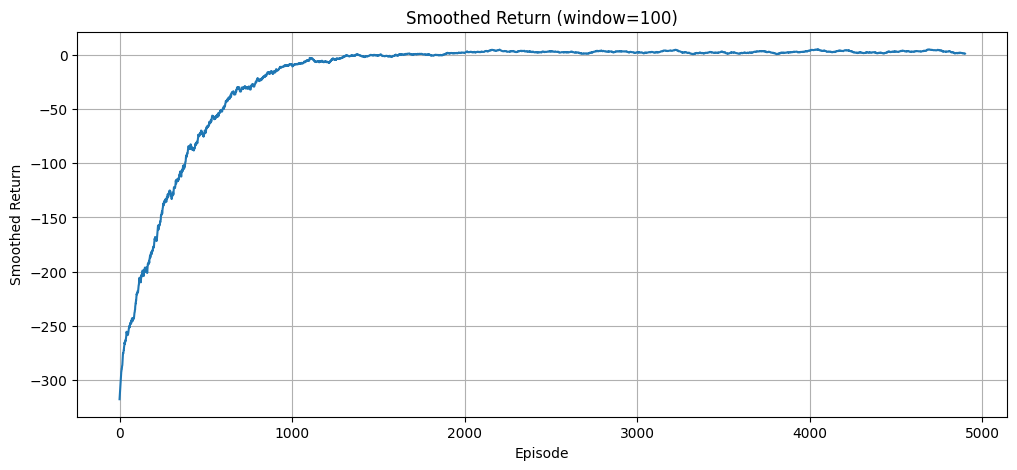

In [54]:
window = 100
smoothed = np.convolve(returns, np.ones(window)/window, mode='valid')

plt.figure(figsize=(12,5))
plt.plot(smoothed)
plt.title(f"Smoothed Return (window={window})")
plt.xlabel("Episode")
plt.ylabel("Smoothed Return")
plt.grid(True)
plt.show()

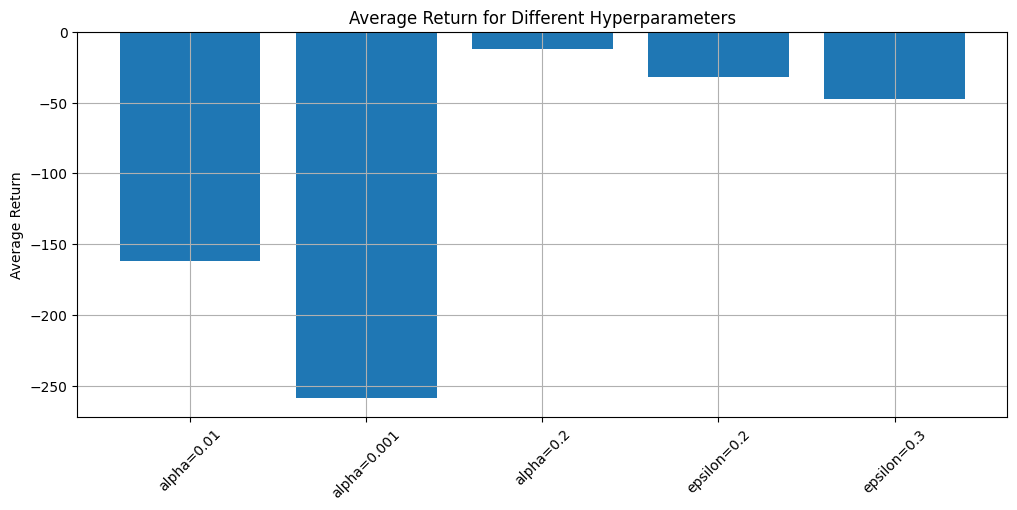

In [55]:
results = {}

alphas = [0.01, 0.001, 0.2]

for a in alphas:
    agent = Agent(num_states, num_actions, alpha=a, epsilon=0.1, gamma=0.9)
    returns, steps = agent.train(env, num_episodes=5000)

    # Store results in the dictionary
    results[f"alpha={a}"] = {
        "returns": returns,
        "steps": steps
    }

epsilons = [0.2, 0.3]

for e in epsilons:
    agent = Agent(num_states, num_actions, alpha=0.1, epsilon=e, gamma=0.9)
    returns, steps = agent.train(env, num_episodes=5000)

    results[f"epsilon={e}"] = {
        "returns": returns,
        "steps": steps
    }

labels = []
avg_returns = []

# Bar chart comparing average returns
for key, metrics in results.items():
    labels.append(key)
    avg_returns.append(np.mean(metrics["returns"]))

plt.figure(figsize=(12,5))
plt.bar(labels, avg_returns)
plt.title("Average Return for Different Hyperparameters")
plt.ylabel("Average Return")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


In [56]:
print(results)

{'alpha=0.01': {'returns': [-524, -587, -596, -452, -515, -560, -551, -542, -371, -542, -416, -281, -524, -416, -551, -245, -488, -605, -533, -254, -272, -524, -98, -416, -470, -542, -398, -254, -316, -362, -317, -272, -60, -335, -242, -335, -299, -317, -254, -180, -272, -272, -155, -100, -236, -299, -245, -317, -272, -299, -281, -236, -254, -263, -236, -281, -281, -45, -425, -218, -281, -276, -263, -236, -245, -245, -263, -236, -299, -236, -274, -263, -281, -188, -281, -443, -362, -389, -245, -263, -129, -132, -371, -308, -245, -335, -258, -263, -328, -263, -371, -398, -353, -335, -290, -189, -461, -236, -299, -308, -290, -380, -73, -245, -272, -254, -398, -308, -335, -166, -263, -308, -245, -272, -272, -281, -281, -272, -407, -137, -266, -73, -272, -290, -245, -290, -254, -290, -263, -263, -434, -299, -34, -236, -371, -245, -272, -254, -272, -389, -308, -263, -245, -317, -245, -281, -307, -272, -272, -236, -227, -272, -335, -308, -272, -218, -299, -341, -281, -407, -58, -263, -281, -

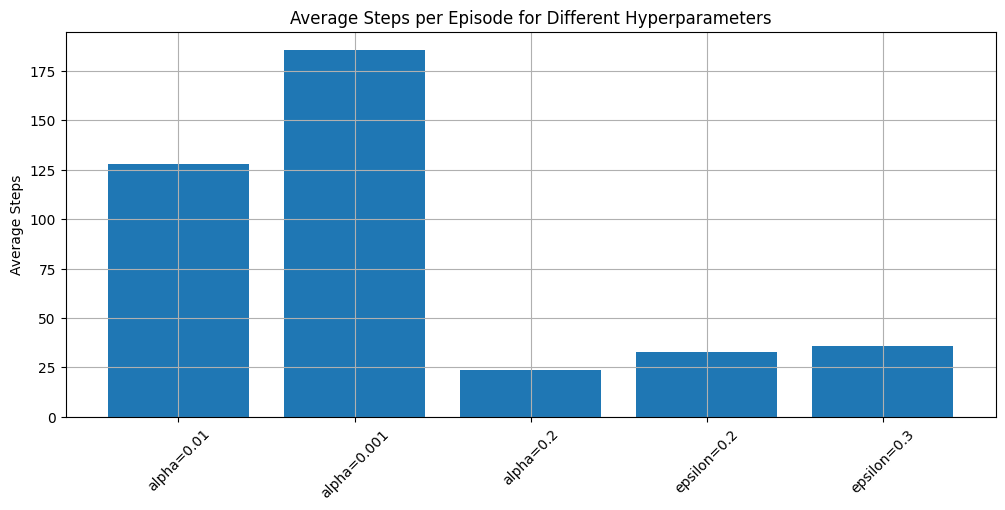

In [57]:
labels = []
avg_steps = []

for key, metrics in results.items():
    labels.append(key)
    avg_steps.append(np.mean(metrics["steps"]))

# Bar chart comparing average steps
plt.figure(figsize=(12,5))
plt.bar(labels, avg_steps)
plt.title("Average Steps per Episode for Different Hyperparameters")
plt.ylabel("Average Steps")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


In [58]:
for key, metrics in results.items():
    print(key, "avg return:", np.mean(metrics["returns"]))

alpha=0.01 avg return: -161.828
alpha=0.001 avg return: -259.1164
alpha=0.2 avg return: -11.961
epsilon=0.2 avg return: -32.2736
epsilon=0.3 avg return: -47.142


In [59]:
for key, metrics in results.items():
    print(key, "avg steps:", np.mean(metrics["steps"]))

alpha=0.01 avg steps: 128.0042
alpha=0.001 avg steps: 185.5822
alpha=0.2 avg steps: 23.7786
epsilon=0.2 avg steps: 32.663
epsilon=0.3 avg steps: 36.018


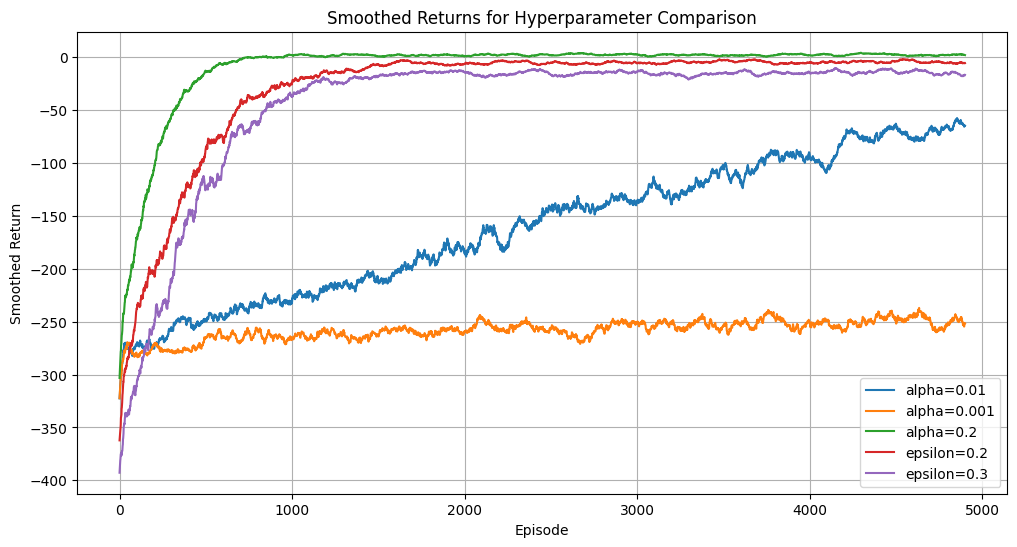

In [60]:
window = 100

plt.figure(figsize=(12,6))
for key, metrics in results.items():
    smoothed = np.convolve(metrics["returns"], np.ones(window)/window, mode='valid')
    plt.plot(smoothed, label=key)

plt.title("Smoothed Returns for Hyperparameter Comparison")
plt.xlabel("Episode")
plt.ylabel("Smoothed Return")
plt.legend()
plt.grid(True)
plt.show()

# Q-table heatmap

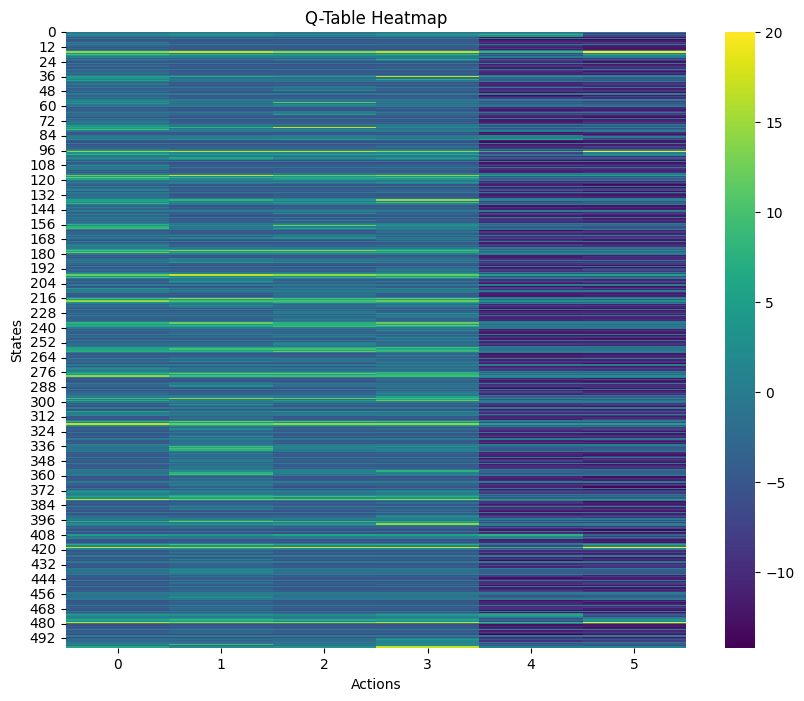

In [61]:
plt.figure(figsize=(10,8))
sns.heatmap(agent.Q, cmap="viridis")
plt.title("Q-Table Heatmap")
plt.xlabel("Actions")
plt.ylabel("States")
plt.show()

# Policy visualization

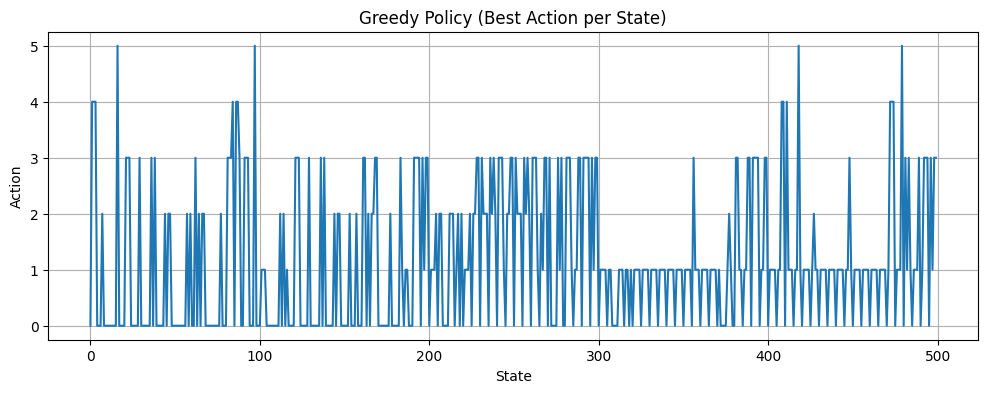

In [62]:
policy = np.argmax(agent.Q, axis=1)

plt.figure(figsize=(12,4))
plt.plot(policy)
plt.title("Greedy Policy (Best Action per State)")
plt.xlabel("State")
plt.ylabel("Action")
plt.grid(True)
plt.show()

# Run Taxi

In [63]:
main()

Observation space:  Discrete(500)
Observation space size:  500
Reward Range:  (-inf, inf)
Number of actions:  6
Action description:  {0: 'Move south (down)', 1: 'Move north (up)', 2: 'Move east (right)', 3: 'Move west (left)', 4: 'Pickup passenger', 5: 'Drop off passenger'}

=== Training with base hyperparameters ===
Total episodes: 5000
Average return: -21.1568
Average steps: 30.1472

=== Testing different learning rates 1 ===
alpha=0.01: avg return=-161.2516, avg steps=127.6144
alpha=0.001: avg return=-258.9726, avg steps=185.5788
alpha=0.2: avg return=-11.1718, avg steps=23.3344

=== Testing different learning rates 2 ===
alpha=0.01: avg return=-160.4442, avg steps=126.9504


KeyboardInterrupt: 